In [14]:
print("Hello ECM")

Hello ECM


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import io
from skimage import filters
from skimage import morphology
from skimage import measure

print("Everything imported successfully")

Everything imported successfully


In [16]:
import os

print(os.getcwd())

/Users/arushiverma/Library/Mobile Documents/com~apple~CloudDocs/Documents/ECM


In [17]:
img = io.imread("Data/In113_113In_Collagen (1).tiff")

print("Shape:", img.shape)
print("Datatype:", img.dtype)
print("Min:", img.min())
print("Max:", img.max())

Shape: (1200, 1200)
Datatype: float32
Min: 0.0
Max: 65.5


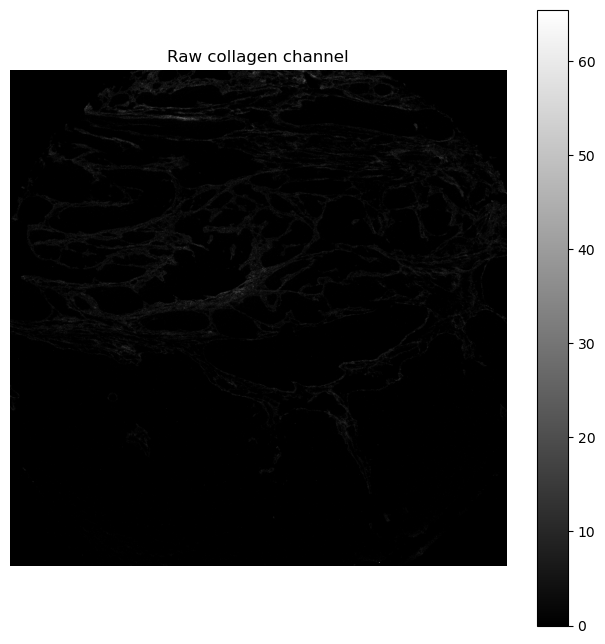

In [18]:

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.colorbar()
plt.title("Raw collagen channel")
plt.axis("off")
plt.show()

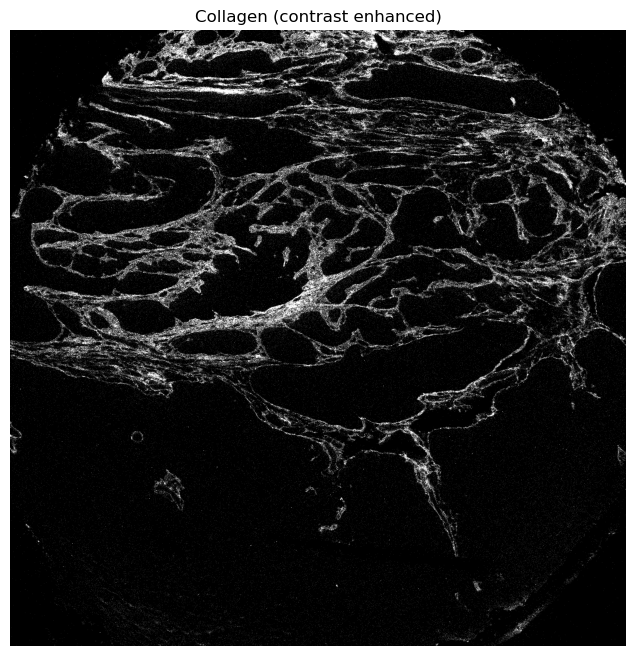

In [19]:
plt.figure(figsize=(8,8))

plt.imshow(img,
           cmap="gray",
           vmin=0,
           vmax=np.percentile(img,99))

plt.title("Collagen (contrast enhanced)")
plt.axis("off")
plt.show()

In [20]:
# import Otsu threasholding function, otsu automatically 
# finds a cutoff that separates bright collagen pixels
# from dark background pixels
from skimage.filters import threshold_otsu

#calculate the optimal threshold value for this image

threshold = threshold_otsu(img)

# create a binary collagen mask where :
# pixels above threshold = collagen (true)
# pixels below threshold = background (False)

collagen_mask = img > threshold

print("Threshold:", threshold)

#calculate collagen area fraction, since True = 1
#and false = 0, the mean = (# collagen pixels / total pixels)

# Gives percentage of tissue area contains collagen

area_fraction = collagen_mask.mean()

print("Collagen area fraction:", area_fraction)

Threshold: 2.430664
Collagen area fraction: 0.0891798611111111


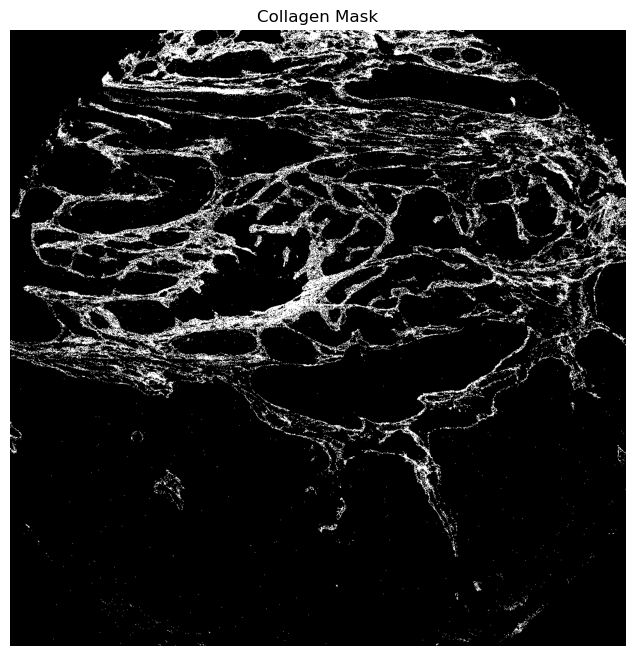

In [21]:
#Display the binary collagen mask, while = collage, black = background

plt.figure(figsize=(8,8))
plt.imshow(collagen_mask, cmap="gray")
plt.title("Collagen Mask")
plt.axis("off")
plt.show()

In [22]:
import matplotlib.pyplot as plt

In [23]:
plt.imsave(
    "Results/collagen_mask.png",
    collagen_mask,
    cmap="gray"
)

In [24]:
import pandas as pd
import os

# Create Features folder if it does not exist
os.makedirs("Features", exist_ok=True)

# Store this image's extracted feature(s) in a table
features = pd.DataFrame({
    "Sample_ID": ["C01_S02_Bavi_TMA_018"],
    "Channel": ["Collagen"],
    "Otsu_Threshold": [threshold],
    "Collagen_AreaFraction": [area_fraction]
})

# Save feature table as CSV
features.to_csv("Features/collagen_features.csv", index=False)

features

,Sample_ID,Channel,Otsu_Threshold,Collagen_AreaFraction
0,C01_S02_Bavi_TMA_018,Collagen,2.430664,0.08918
